# **Treinamento do Modelo – Fake News Detection (RoBERTa)**


Este notebook realiza o fine-tuning do modelo **RoBERTa-base** utilizando **LoRA (Low-Rank Adaptation)** para reduzir o consumo de memória GPU, além de ativar gradient checkpointing e reduzir o max_length para 256.

In [1]:
# Instalações e Imports
!pip install -q transformers datasets accelerate sentencepiece scikit-learn lime matplotlib seaborn peft

import pandas as pd
import numpy as np
import torch
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model  # LoRA
from lime.lime_text import LimeTextExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Carregar dados
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Treino original:", train.shape)
print("Teste original:", test.shape)
print("\nColunas do treino:", train.columns.tolist())


Treino original: (22844, 6)
Teste original: (5712, 5)

Colunas do treino: ['id', 'title', 'text', 'subject', 'date', 'label']


In [3]:
# Criar grupos para split (evitar vazamento)
train["group"] = train["title"].fillna("") + " " + train["text"].fillna("")
train["group_hash"] = train["group"].apply(lambda x: hashlib.md5(x.encode()).hexdigest())

gss = GroupShuffleSplit(test_size=0.1, random_state=42)
train_idx, val_idx = next(gss.split(train, groups=train["group_hash"]))

train_df = train.iloc[train_idx].copy().reset_index(drop=True)
val_df = train.iloc[val_idx].copy().reset_index(drop=True)

print(f"\nTreino após split: {train_df.shape}")
print(f"Validação: {val_df.shape}")



Treino após split: (20553, 8)
Validação: (2291, 8)


In [4]:
# Preparar o conteúdo textual
def build_text(df):
    """
    Junta título e texto, removendo a palavra 'reuters' (case insensitive)
    para eliminar o viés identificado na EDA.
    """
    text = df["text"].fillna("")
    text = text.str.replace(r'\breuters\b', '', case=False, regex=True)
    content = (df["title"].fillna("") + " " + text).str.strip()
    return content

train_df["content"] = build_text(train_df)
val_df["content"] = build_text(val_df)
test["content"] = build_text(test)


In [5]:
# Tokenização
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LENGTH = 256

def tokenize_function(batch):
    return tokenizer(
        batch["content"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_ds = Dataset.from_pandas(train_df[["content", "label"]])
val_ds = Dataset.from_pandas(val_df[["content", "label"]])

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/20553 [00:00<?, ? examples/s]

Map:   0%|          | 0/2291 [00:00<?, ? examples/s]

In [6]:
# Carregar modelo base e aplicar LoRA
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [7]:
# Definir métrica (F1 Macro)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"f1_macro": macro_f1}

# Configurar treinamento (com early stopping e gradient checkpointing)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,                       # Mixed precision para reduzir memória
    gradient_checkpointing=True,      # Gradient checkpointing: troca compute por memória
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)



In [8]:
# Treinar
trainer.train()



Epoch,Training Loss,Validation Loss,F1 Macro
1,0.000104,0.001008,0.998798
2,0.000006,0.000032,1.000000
3,0.000008,0.000001,1.000000
4,0.000001,0.000286,1.000000


TrainOutput(global_step=10280, training_loss=0.015661157850277562, metrics={'train_runtime': 1398.7345, 'train_samples_per_second': 73.47, 'train_steps_per_second': 9.187, 'total_flos': 1.0927456604872704e+16, 'train_loss': 0.015661157850277562, 'epoch': 4.0})

In [11]:
# Salvar modelo final (incluindo adaptadores LoRA)
model.save_pretrained("./modelo_final_lora")
tokenizer.save_pretrained("./modelo_final_lora")
print("\nModelo LoRA salvo em ./modelo_final_lora")



Modelo LoRA salvo em ./modelo_final_lora


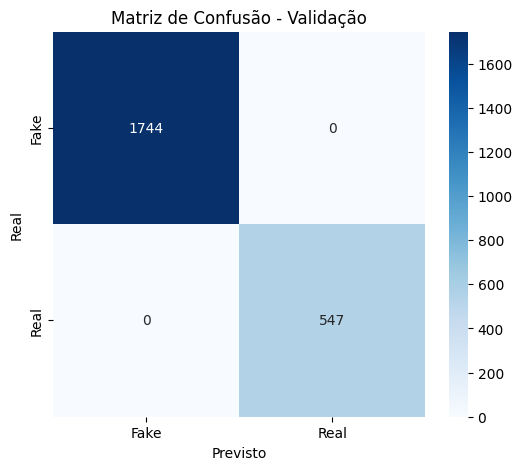


Relatório de Classificação:
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      1744
    Real (1)       1.00      1.00      1.00       547

    accuracy                           1.00      2291
   macro avg       1.00      1.00      1.00      2291
weighted avg       1.00      1.00      1.00      2291


F1 Macro na validação: 1.0000


In [14]:
# Avaliação detalhada no conjunto de validação
val_preds = trainer.predict(val_ds)
y_true = val_preds.label_ids
y_pred = val_preds.predictions.argmax(axis=1)

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Validação')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=['Fake (0)', 'Real (1)']))

# F1 Macro
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"\nF1 Macro na validação: {f1_macro:.4f}")

In [15]:
# Análise de erros
val_df["pred"] = y_pred
val_df["correct"] = (val_df["label"] == val_df["pred"])

erros = val_df[~val_df["correct"]]
print(f"\nTotal de erros na validação: {len(erros)}")
print("\nExemplos de erros (primeiros 5):")
for i, row in erros.head(5).iterrows():
    print(f"ID: {row['id']} | Real: {row['label']} | Previsto: {row['pred']}")
    print(f"Texto: {row['content'][:300]}...\n")



Total de erros na validação: 0

Exemplos de erros (primeiros 5):


In [17]:
# Explicabilidade com LIME (XAI)
def predictor(texts):
    all_probs = []
    batch_size = 8
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)

exemplos_xai = val_df.groupby('label').sample(2, random_state=42).reset_index(drop=True)

explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

for idx, row in exemplos_xai.iterrows():
    texto = row['content']
    rotulo_real = row['label']
    print(f"\n--- Explicação ID {row['id']} (Real: {rotulo_real}) ---")
    exp = explainer.explain_instance(
        texto,
        predictor,
        num_features=10,
        top_labels=1
    )
    print("Palavras mais importantes:")
    for word, weight in exp.as_list(label=rotulo_real):
        print(f"  {word}: {weight:.4f}")



--- Explicação ID 15375 (Real: 0) ---
Palavras mais importantes:
  WASHINGTON: 0.1436
  Thursday: 0.1185
  spokesman: 0.0916
  U: 0.0842
  S: 0.0755
  Democratic: 0.0752
  said: 0.0692
  Clinton: 0.0691
  campaign: 0.0649
  a: 0.0604

--- Explicação ID 26698 (Real: 0) ---
Palavras mais importantes:
  LAHORE: 0.2930
  of: 0.1210
  Pakistan: 0.1194
  eyes: 0.0997
  The: 0.0952
  said: 0.0880
  Pakistani: 0.0852
  killer: 0.0812
  party: 0.0779
  Inspired: 0.0032

--- Explicação ID 3328 (Real: 1) ---
Palavras mais importantes:
  If: 0.0000
  Do: 0.0000
  Over: 0.0000
  he: 0.0000
  By: 0.0000
  He: 0.0000
  Tweet: 0.0000
  Called: 0.0000
  s: 0.0000
  realDonaldTrump: -0.0000

--- Explicação ID 544 (Real: 1) ---
Palavras mais importantes:
  Broadcaster: 0.0000
  VIDEO: 0.0000
  Afraid: 0.0000
  Presley: 0.0000
  Teenage: 0.0000
  For: 0.0000
  Is: 0.0000
  Girl: 0.0000
  grandfather: 0.0000
  wing: 0.0000


In [18]:
#  Gerar previsões para o teste e arquivo de submissão
test_ds = Dataset.from_pandas(test[["content"]])
test_ds = test_ds.map(tokenize_function, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask"])

test_preds = trainer.predict(test_ds)
test_labels = test_preds.predictions.argmax(axis=1)

submission = pd.DataFrame({
    "id": test["id"],
    "target": test_labels
})
submission.to_csv("submission.csv", index=False)
print("\nArquivo submission.csv gerado com sucesso!")

Map:   0%|          | 0/5712 [00:00<?, ? examples/s]


Arquivo submission.csv gerado com sucesso!
